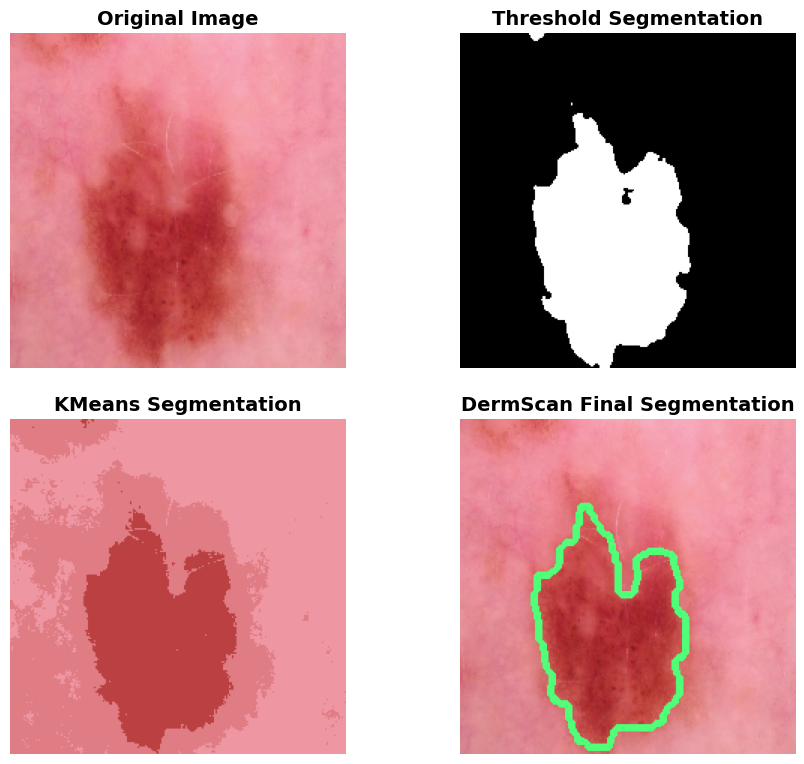

Saved: Figure_2_3_Segmentation_Comparison.png


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# CHANGE IMAGE PATH
# ==========================
IMAGE_PATH = "sample_lesion.jpg"   # put one lesion image here

IMG_SIZE = (224, 224)

# ==========================
# LOAD
# ==========================
img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, IMG_SIZE)

# ==========================
# 1) THRESHOLD SEGMENTATION
# ==========================
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

threshold_vis = cv2.cvtColor(thresh, cv2.COLOR_GRAY2RGB)

# ==========================
# 2) KMEANS SEGMENTATION
# ==========================
data = img.reshape((-1,3)).astype(np.float32)

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    20,
    1.0
)

K = 3

_, labels, centers = cv2.kmeans(
    data,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)

kmeans_img = centers[labels.flatten()]
kmeans_img = kmeans_img.reshape(img.shape)

# ==========================
# 3) FINAL DERMSCAN METHOD
# ==========================
gray_seg = cv2.cvtColor(kmeans_img, cv2.COLOR_RGB2GRAY)

cluster_vals = [
    np.mean(gray_seg[labels.reshape(224,224)==i])
    for i in range(K)
]

lesion_cluster = int(np.argmin(cluster_vals))

mask = (
    labels.reshape(224,224)==lesion_cluster
).astype(np.uint8)*255

kernel = np.ones((7,7), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = img.copy()

if contours:
    best = max(contours, key=cv2.contourArea)

    cv2.drawContours(
        overlay,
        [best],
        -1,
        (80,255,120),
        3
    )

# ==========================
# SHOW FIGURE
# ==========================
# ==========================
# SHOW FIGURE (2x2 Layout)
# ==========================
fig, ax = plt.subplots(
    2,
    2,
    figsize=(10, 8)   # A4 friendly
)

ax[0,0].imshow(img)
ax[0,0].set_title(
    "Original Image",
    fontsize=14,
    fontweight="bold"
)

ax[0,1].imshow(threshold_vis)
ax[0,1].set_title(
    "Threshold Segmentation",
    fontsize=14,
    fontweight="bold"
)

ax[1,0].imshow(kmeans_img)
ax[1,0].set_title(
    "KMeans Segmentation",
    fontsize=14,
    fontweight="bold"
)

ax[1,1].imshow(overlay)
ax[1,1].set_title(
    "DermScan Final Segmentation",
    fontsize=14,
    fontweight="bold"
)

for row in ax:
    for a in row:
        a.axis("off")

plt.tight_layout(
    pad=2.0
)

plt.savefig(
    "Figure_2_3_Segmentation_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Figure_2_3_Segmentation_Comparison.png")